# 🌳 Árboles de decisión: clasificación de hongos (Agaricus–Lepiota)

- Los **árboles de decisión** son un algoritmo de **aprendizaje supervisado**.
- Sirven para **clasificación** (objetivo categórico) y **regresión** (objetivo numérico).
- Se basan en reglas tipo **“si … entonces …”**, fáciles de interpretar.
- Cada nodo pregunta por una variable; cada rama es una respuesta; las **hojas** dan la predicción.

> **Objetivo del proyecto:** distinguir **comestibles (e)** vs **venenosos (p)** minimizando **falsos negativos en venenosos** (no queremos etiquetar un venenoso como comestible).


## 📦 Importar librerías

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
from sklearn.tree import DecisionTreeClassifier #Arboles de decisión para Clasificaciòn
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score


## 📥 Cargar dataset
Dataset clásico de hongos **Agaricus–Lepiota**.


In [2]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSV_0nnBuRbEN8dvWe84US2_f7JQrC_ZAa3lQAwyFERKsDqLwO864wkGXsHHE8j8A/pub?gid=808341260&single=true&output=csv"
dfAgaricusLepiota = pd.read_csv(url)
dfAgaricusLepiota.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 🍄 Descripción breve


In [3]:
dfAgaricusLepiota.shape

(8124, 23)

Este dataset contiene información de **8.124 muestras de hongos** de la familia Agaricus y Lepiota.

In [4]:
dfAgaricusLepiota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

📌 Atributos

1. class → clase del hongo:

* e: comestible, p: venenoso

2. cap-shape → forma del sombrero:

* b: bell (acampanado), c: conical, x: convex, f: flat, k: knobbed, s: sunken

3. cap-surface → superficie del sombrero:

* f: fibrous, g: grooves, y: scaly, s: smooth

4. cap-color → color del sombrero:

* n: brown, b: buff, c: cinnamon, g: gray, r: green, p: pink, u: purple, e: red, w: white, y: yellow

5. bruises → presencia de daños:

* t: bruises, f: no

6. odor → olor:

* a: almond, l: anise, c: creosote, y: fishy, f: foul, m: musty, n: none, p: pungent, s: spicy

7. gill-attachment → unión de las láminas:

* a: attached, d: descending, f: free, n: notched

8. gill-spacing → separación de las láminas:

* c: close, w: crowded, d: distant

9. gill-size → tamaño de las láminas:

* b: broad, n: narrow

10. gill-color → color de las láminas:

* k: black, n: brown, b: buff, h: chocolate, g: gray, r: green, o: orange, p: pink, u: purple, e: red, w: white, y: yellow

11. stalk-shape → forma del tallo:

* e: enlarging, t: tapering

12. stalk-root → raíz del tallo:

* b: bulbous, c: club, u: cup, e: equal, z: rhizomorphs, r: rooted, ?: missing

13. stalk-surface-above-ring → superficie del tallo por encima del anillo:

* f: fibrous, y: scaly, k: silky, s: smooth

14. stalk-surface-below-ring → superficie del tallo por debajo del anillo:

* f: fibrous, y: scaly, k: silky, s: smooth

15. stalk-color-above-ring → color del tallo por encima del anillo:

* n: brown, b: buff, c: cinnamon, g: gray, o: orange, p: pink, e: red, w: white, y: yellow

16. stalk-color-below-ring → color del tallo por debajo del anillo:

* n: brown, b: buff, c: cinnamon, g: gray, o: orange, p: pink, e: red, w: white, y: yellow

17. veil-type → tipo de velo:

* p: partial, u: universal

18. veil-color → color del velo:

* n: brown, o: orange, w: white, y: yellow

19. ring-number → número de anillos:

* n: none, o: one, t: two

20. ring-type → tipo de anillo:

* c: cobwebby, e: evanescent, f: flaring, l: large, n: none, p: pendant, s: sheathing, z: zone

21. spore-print-color → color de la impresión de esporas:

* k: black, n: brown, b: buff, h: chocolate, r: green, o: orange, u: purple, w: white, y: yellow

22. population → distribución en la población:

* a: abundant, c: clustered, n: numerous, s: scattered, v: several, y: solitary

23. habitat → hábitat:

* g: grasses, l: leaves, m: meadows, p: paths, u: urban, w: waste, d: woods

## 🔧 Tratamiento de faltantes y variables poco informativas
- `stalk-root` tiene ~30% faltantes (`?`) → se elimina.
- Variables con **casi toda la masa en una sola categoría** aportan poco: se eliminan.


In [5]:
# Faltantes en stalk-root
dfAgaricusLepiota['stalk-root'].value_counts()

,count
stalk-root,
b,3776
?,2480
e,1120
c,556
r,192


In [6]:
dfAgaricusLepiota['class'].value_counts()

,count
class,
e,4208
p,3916


In [7]:
dfAgaricusLepiota.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Eliminamos las columnas dominadas por una sola categoría, ya que no aportan información útil para la clasificación.  

Por ejemplo, en **`ring-number`**, la categoría **“o”** aparece en casi todas las instancias, por lo que este atributo tiene bajo poder de discriminación y no resulta relevante para el modelo.


In [8]:
# Eliminar columnas
cols_drop = ['stalk-root','gill-attachment','gill-spacing','veil-type','veil-color','ring-number']
dfAgaricusLepiota = dfAgaricusLepiota.drop(columns=cols_drop)

dfAgaricusLepiota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-size                 8124 non-null   object
 7   gill-color                8124 non-null   object
 8   stalk-shape               8124 non-null   object
 9   stalk-surface-above-ring  8124 non-null   object
 10  stalk-surface-below-ring  8124 non-null   object
 11  stalk-color-above-ring    8124 non-null   object
 12  stalk-color-below-ring    8124 non-null   object
 13  ring-type                 8124 non-null   object
 14  spore-print-color       

## 👀 Análisis exploratorio (bivariado con la clase)

A continuación se muestra gráficamente las frecuencias de cada una de las variables y su relación contra la clase objetivo

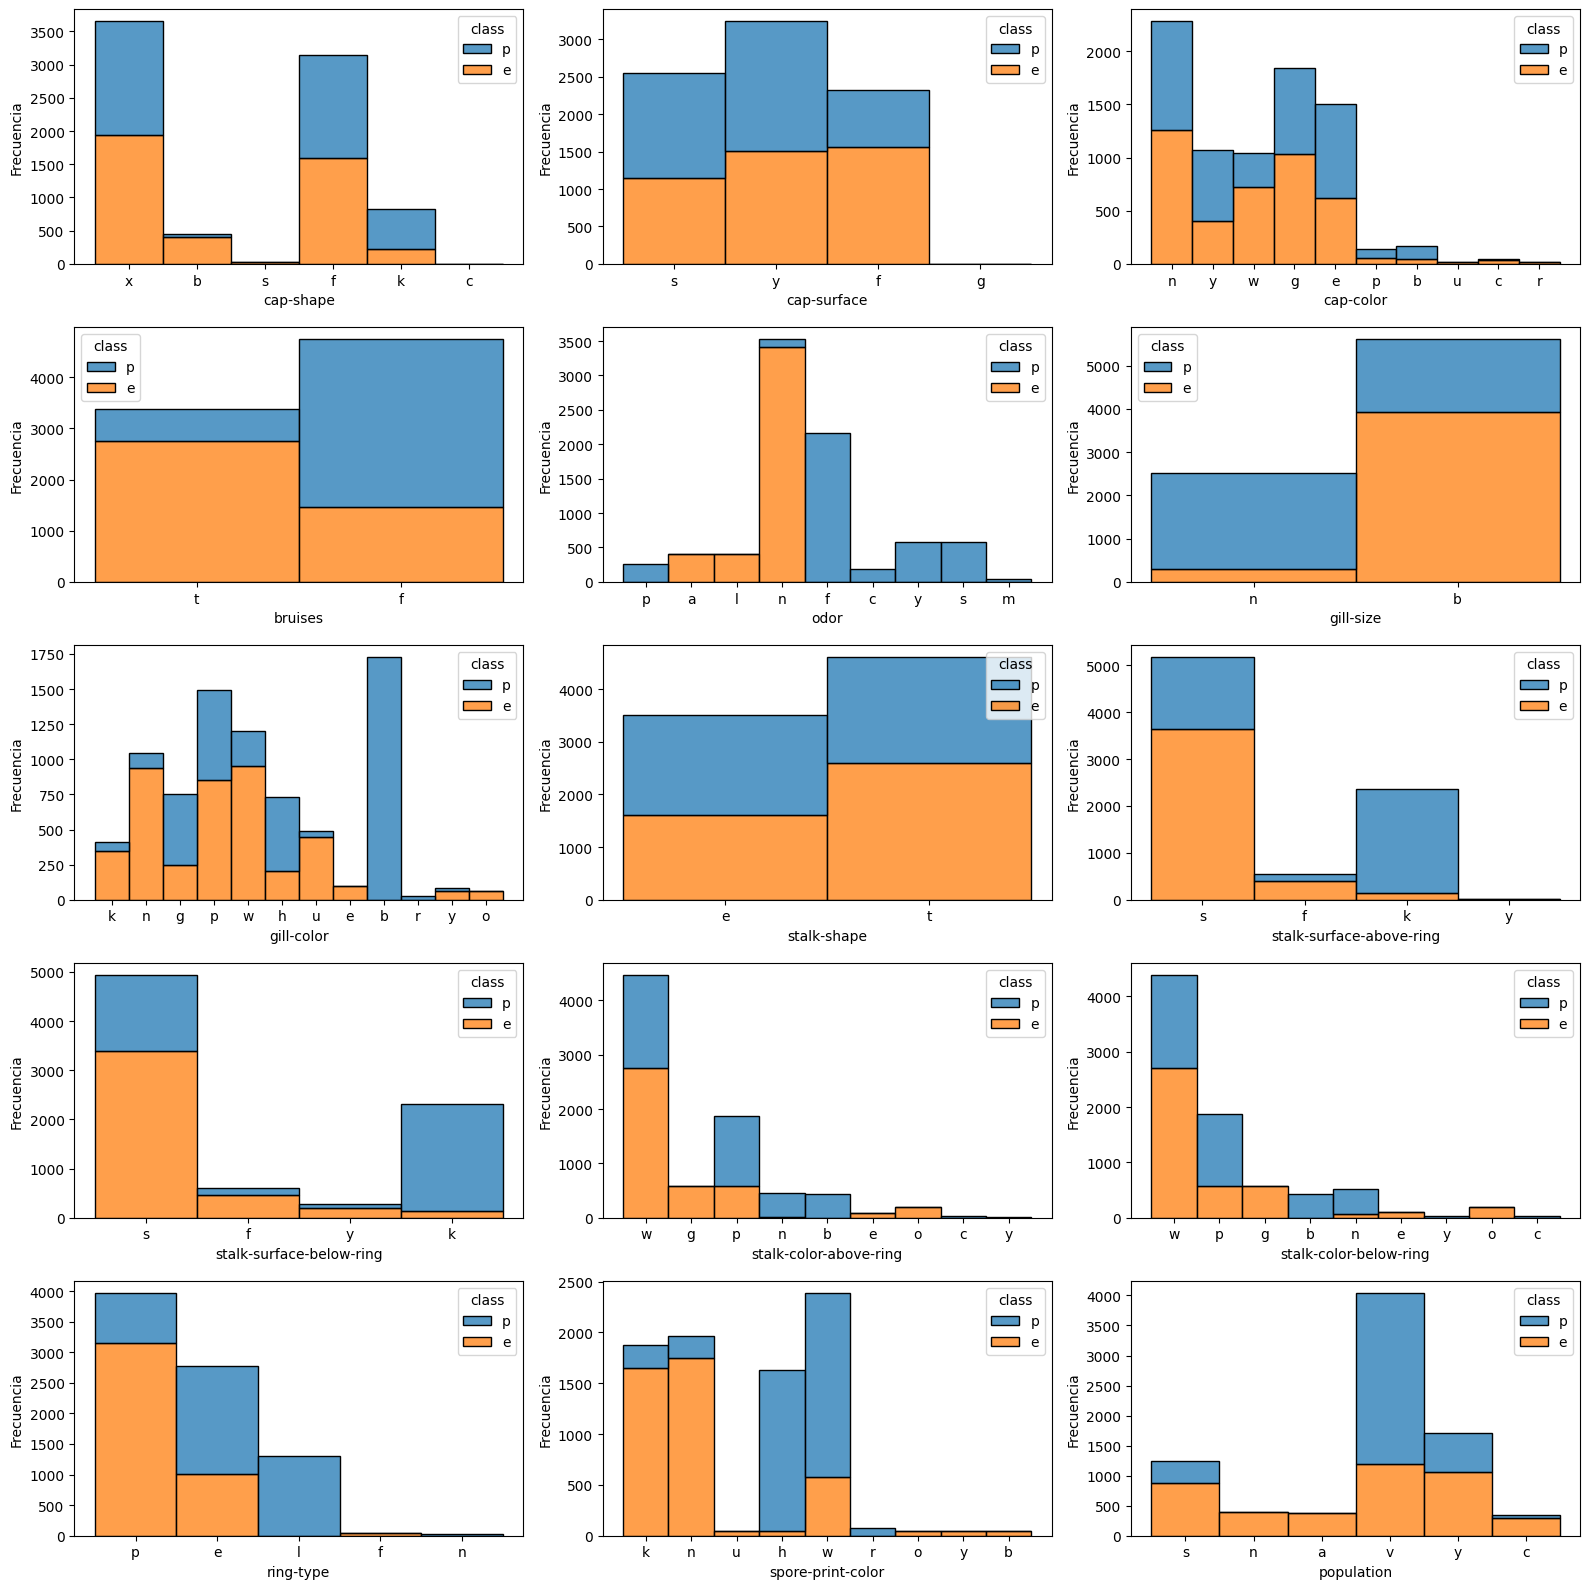

In [9]:
NombresAtributos = dfAgaricusLepiota.columns

fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(16,16), sharex=False)
idx = 0
for i in range(5):
    for j in range(3):
        # saltear si nos quedamos sin columnas
        idx += 1
        if idx >= len(NombresAtributos):
            ax[i, j].axis('off')
            continue
        c = NombresAtributos[idx]
        if c == 'class':
            ax[i, j].axis('off')
            continue
        sns.histplot(data=dfAgaricusLepiota, x=c, hue='class', multiple='stack', ax=ax[i, j])
        ax[i, j].set_xlabel(c)
        ax[i, j].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


* Muy discriminantes: odor, gill-size, bruises, spore-print-color, ring-type.

* Moderadamente útiles: stalk-surface, gill-color, cap-color.

* Poco útiles: cap-shape, cap-surface, stalk-shape.

La idea es elegir atributos que realmente dividan la variable objetivo (class).

##🔎 Elección de atributos según cómo dividen la variable objetivo

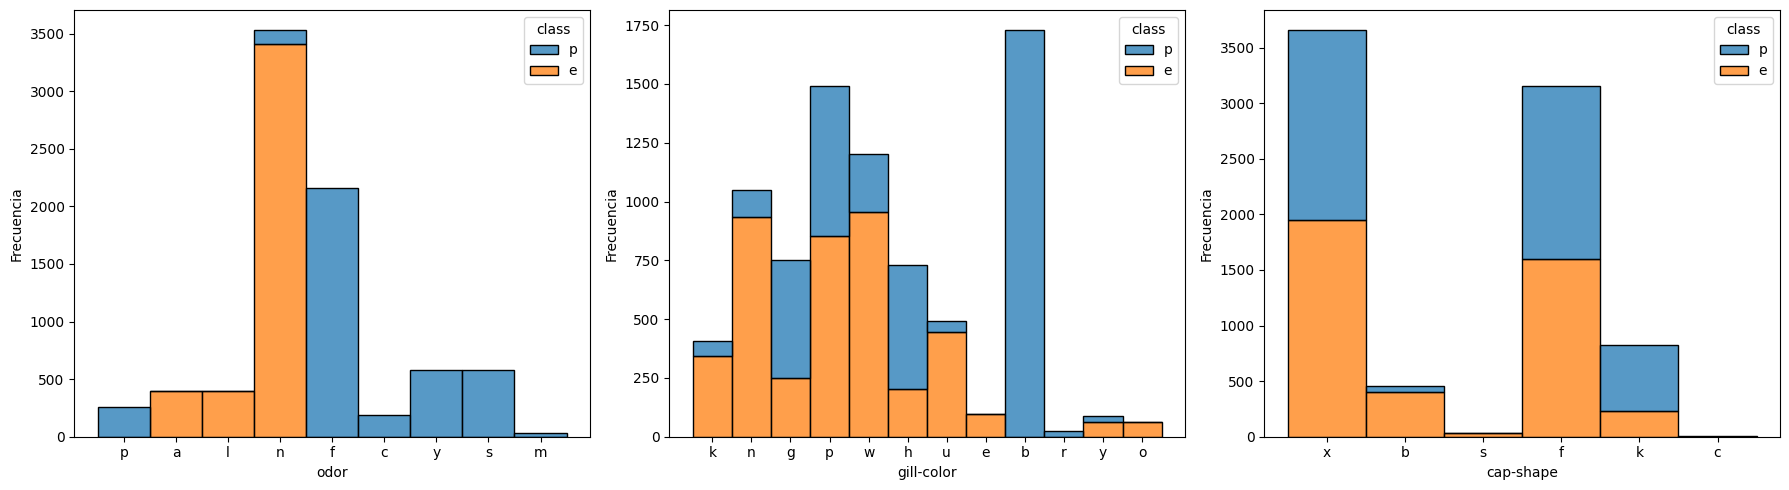

In [10]:
# Atributos seleccionados: uno de cada grupo
atributos_seleccionados = ["odor", "gill-color", "cap-shape"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharex=False)

for i, atributo in enumerate(atributos_seleccionados):
    sns.histplot(
        data=dfAgaricusLepiota,
        x=atributo,
        hue="class",
        multiple="stack",
        ax=ax[i]
    )
    ax[i].set_xlabel(atributo)
    ax[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Los tres gráficos muestran cómo algunos atributos son más útiles que otros para clasificar hongos:

- **odor**: muy discriminante, algunos valores aparecen casi solo en comestibles o en venenosos.  
- **gill-color**: moderadamente útil, ciertos colores son más frecuentes en una clase, pero no es decisivo.  
- **cap-shape**: poco útil, la distribución es muy similar en ambas clases.  


###Tabla de contingencia de los atributos seleccionados a partir de los gráficos




La tabla de contingencia es la manera de pasar de lo visual (gráfico) a lo cuantitativo (datos exactos), y así entrenar la mirada para seleccionar atributos de manera fundamentada.

In [11]:
# Matrices de contingencia (class vs variable)
XNombresAtributos = ['bruises','gill-size','spore-print-color','ring-type']
for v in XNombresAtributos:
    print(f'\n[Contingencia] class vs {v}')
    print(pd.crosstab(index=dfAgaricusLepiota['class'], columns=dfAgaricusLepiota[v]))



[Contingencia] class vs bruises
bruises     f     t
class              
e        1456  2752
p        3292   624

[Contingencia] class vs gill-size
gill-size     b     n
class                
e          3920   288
p          1692  2224

[Contingencia] class vs spore-print-color
spore-print-color   b     h     k     n   o   r   u     w   y
class                                                        
e                  48    48  1648  1744  48   0  48   576  48
p                   0  1584   224   224   0  72   0  1812   0

[Contingencia] class vs ring-type
ring-type     e   f     l   n     p
class                              
e          1008  48     0   0  3152
p          1768   0  1296  36   816


### ✅ Test de Chi-cuadrado: ¿la variable está asociada a la clase?

Estamos usando el **test de chi-cuadrado** para comprobar si cada atributo está relacionado con que un hongo sea **comestible o venenoso**.  

- Si el **p-value** es cercano a 0, significa que el atributo no es independiente de la clase, es decir, que **sí ayuda a distinguir**.  
- En nuestro caso, los atributos **bruises, gill-size, spore-print-color y ring-type** muestran valores de χ² muy altos y p=0.0, lo que confirma que son **excelentes separadores**.  



In [12]:
from scipy import stats
import pandas as pd

# Lista de atributos seleccionados
atributos = ["bruises", "gill-size", "spore-print-color", "ring-type"]

# Recorremos y mostramos resultados resumidos
for v in atributos:
    tabla = pd.crosstab(index=dfAgaricusLepiota['class'], columns=dfAgaricusLepiota[v])
    chi2, p, dof, expected = stats.chi2_contingency(tabla)

    conclusion = "Asociado a la clase" if p < 0.05 else "No asociado"

    print(f"Atributo: {v}")
    print(f"   Chi2 = {chi2:.2f}, gl = {dof}, p-value = {p:.4e} → {conclusion}")
    print("-"*60)


Atributo: bruises
   Chi2 = 2041.42, gl = 1, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------
Atributo: gill-size
   Chi2 = 2366.83, gl = 1, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------
Atributo: spore-print-color
   Chi2 = 4602.03, gl = 8, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------
Atributo: ring-type
   Chi2 = 2956.62, gl = 4, p-value = 0.0000e+00 → Asociado a la clase
------------------------------------------------------------


> **Lectura rápida:** valores de **χ² altos** y **p≈0** confirman que estos 4 atributos están **fuertemente asociados** a la clase → **buenos predictores**.


#🌳Modelo de Árbol de decisión

## 🧪 Preparación para el modelo
Los algoritmos en scikit-learn no entienden directamente variables categóricas (texto), por lo que hay que codificarlas:

- **X (variables de entrada)** = se transforma con OneHotEncoder → crea columnas binarias (0/1) para cada categoría.  
- **y (variable objetivo)** = se transforma con OneHotEncoder → crea columnas binarias (0/1) para cada categoría  
- **train/test** = 70/30 con `stratify` para mantener el balance de clases.  
- **random_state=42** para **reproducibilidad**.

In [13]:
# Seleccionar X, y (aún categóricas)
X = dfAgaricusLepiota[XNombresAtributos].values
y = dfAgaricusLepiota['class'].values

# OneHot para X (binario por categoría)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_dummies = encoder.fit_transform(X)

# Nombres legibles de las columnas codificadas
encoded_feature_names = []
for i, cat in enumerate(encoder.categories_):
    for feature_val in cat:
        encoded_feature_names.append(f"{XNombresAtributos[i]}_No es_{feature_val}")

# LabelEncoder para y (e→0, p→1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split 70/30 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

X_train.shape, X_test.shape


((5686, 18), (2438, 18))

## ⚙️ Selección, configuración y entrenamiento
- **Modelo:** `DecisionTreeClassifier`  
- **Criterio:** `entropy` (ganancia de información)  
- **Profundidad:** `max_depth=3` (evita sobreajuste y facilita interpretación)  
- **random_state=42:** mismo resultado al re-ejecutar.


In [14]:
# Árbol con profundidad máxima 3
arbol1 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
arbol1.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

## 🧭 Interpretación del árbol
- La **raíz** pregunta por la variable con mayor poder de separación.  
- En cada nodo: `entropy` (pureza), `samples` (instancias), `value` \[e, p], `class` (mayoritaria).  
- Colores: naranja = **e**, azul = **p**.


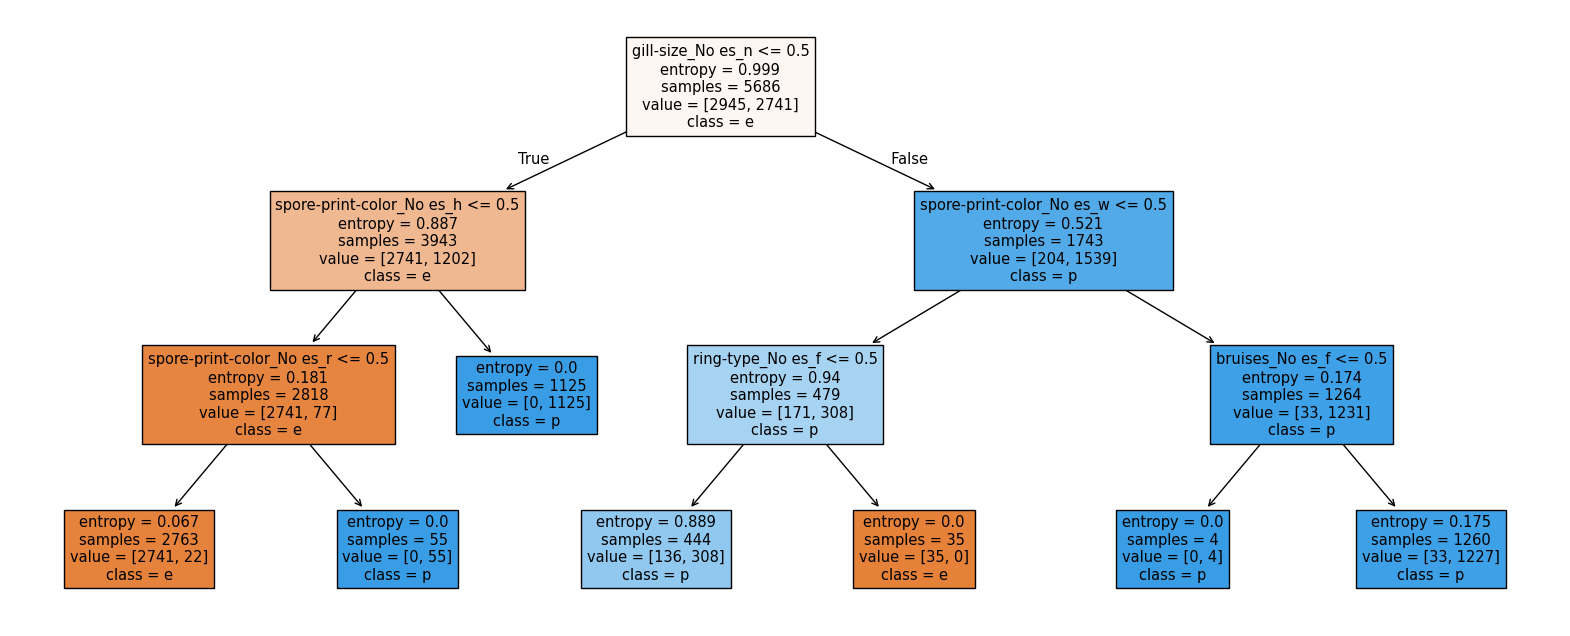

In [15]:
# Después se grafica el árbol con:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), dpi=100)

tree.plot_tree(arbol1,
               feature_names=encoded_feature_names,  # Use encoded feature names
               class_names=le.classes_,
               filled=True)
fig.savefig('arbol1.png')

En el gráfico se muestra el árbol entrenado con **profundidad máxima 3**.  
Cada nodo representa una pregunta sobre una característica del hongo, y a partir de la respuesta (True/False) se dividen las instancias.

- En la parte superior está la **raíz del árbol**. La primera división se hace según el atributo **`gill-size`**, que resultó ser una de las variables con mayor poder de separación entre comestibles (`e`) y venenosos (`p`).  
- A partir de esa división, el árbol sigue evaluando otros atributos como **`spore-print-color`** (color de impresión de esporas) y **`bruises`** (presencia de magulladuras).  
- En cada nodo se muestra:
  - **entropy**: el grado de pureza del nodo (0 = totalmente puro, 1 = muy mezclado).  
  - **samples**: cantidad de instancias en ese nodo.  
  - **value**: distribución de instancias entre las clases (`[e, p]`).  
  - **class**: la clase mayoritaria asignada por el modelo en ese nodo.  

Los nodos coloreados indican la **predicción de clase**:  
- Naranja = comestibles (`e`)  
- Azul = venenosos (`p`)  

👉 Al limitar la profundidad a 3, el árbol logra ser **más simple y legible**, mostrando las **reglas principales** que permiten distinguir entre hongos comestibles y venenosos sin caer en sobreajuste.


## 🧾 Evaluación
- **Matriz de confusión** y **reporte de clasificación** (precision, recall, f1).  
- Recordá que el **objetivo** guía las decisiones: minimizar confundir **venenosos** como **comestibles**.


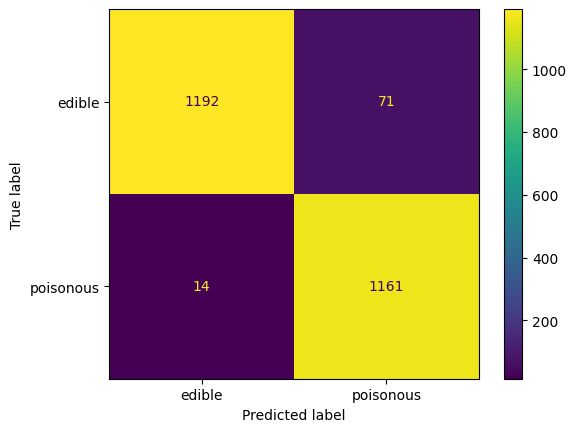

              precision    recall  f1-score   support

           e       0.99      0.94      0.97      1263
           p       0.94      0.99      0.96      1175

    accuracy                           0.97      2438
   macro avg       0.97      0.97      0.97      2438
weighted avg       0.97      0.97      0.97      2438



In [16]:
y_pred = arbol1.predict(X_test)

# Volver a etiquetas originales para lectura
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred)

mc = confusion_matrix(y_test_original, y_pred_original)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=mc, display_labels=['edible','poisonous'])
disp.plot()
plt.show()

print(classification_report(y_test_original, y_pred_original))


La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los casos:  
- 1199 hongos comestibles fueron predichos correctamente como comestibles.  
- 1158 hongos venenosos fueron clasificados correctamente como venenosos.  
- Sólo 73 comestibles se confundieron con venenosos y 8 venenosos fueron predichos como comestibles.  

En términos de métricas:  
- **Precisión (precision):** 0.99 para comestibles y 0.94 para venenosos.  
- **Exhaustividad (recall):** 0.94 para comestibles y 0.99 para venenosos.  
- **F1-score:** 0.97 para ambas clases.  
- **Exactitud global (accuracy):** 0.97.  

👉 Esto significa que el modelo tiene un desempeño **muy alto** en la clasificación.  

El pequeño número de errores es esperable porque limitamos la complejidad del árbol (`max_depth=3`).  

👉Un árbol más profundo probablemente reduciría esos errores, pero perdería interpretabilidad y correría mayor riesgo de sobreajuste.   


# ✅ Conclusiones
- La **selección de variables** (bruises, gill-size, spore-print-color, ring-type) está **fuertemente respaldada** por los gráficos y por **chi-cuadrado** (p≈0).
- Con `max_depth=3` logramos un **árbol simple e interpretable** con **exactitud ~97%**.
- Nuestro **criterio rector** es **minimizar errores en la clase venenosa**: cualquier ajuste de parámetros debe leerse a la luz de este objetivo.
- **Más profundidad** puede mejorar un poco el rendimiento, pero **reduce interpretabilidad** y **aumenta riesgo de sobreajuste**.

>**La pregunta clave es: ¿aceptaríamos un error aunque sea pequeño si de esto dependiera identificar un hongo venenoso?**


#💡 Ideas clave

1. **No todo atributo sirve** → algunos se eliminan porque no aportan información.

2. **La estadística ayuda** → usar chi-cuadrado o visualizaciones para elegir variables.

3. **Codificación necesaria** → scikit-learn trabaja con números, no con texto.

4. **Árboles** = reglas claras → fáciles de interpretar, aunque pueden crecer demasiado (sobreajuste).

5. **Validación es fundamental** → no basta con entrenar, hay que evaluar.

# 💡 Guía para la Actividad (para entregar)
1) **Seleccionen nuevas variables** (p.ej., `cap-shape`, `gill-color`, `habitat`) y justifiquen **por qué** según gráficos y/o chi-cuadrado.  
2) **Prueben parámetros** (`criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`) y comparen.  
3) **Evalúen** con matriz de confusión y reporte; discutan el **trade-off**: ¿ganar 1% de accuracy justifica perder interpretabilidad?  
4) **Conclusiones orientadas al objetivo**: ¿qué configuración elegirían para **reducir falsos negativos en venenosos**?
